
**1. (a) & (b)  Gamma correction with γ=0.5 and Gamma correction with γ=2.0**

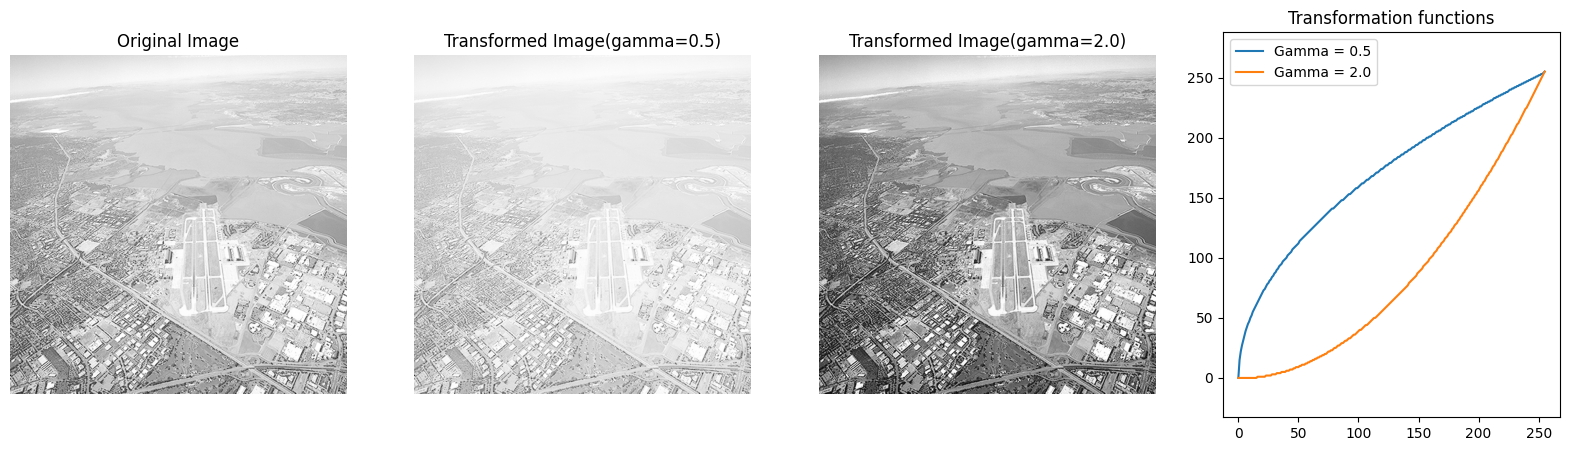

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

f = cv.imread('../MSC Lec notes/3rd sem/Computer Vision/Images/runway.png',cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

gamma1 = 0.5
gamma2 = 2.0
t1 = np.array([((i / 255) ** gamma1) * 255 for i in np.arange(0,256)], dtype=np.uint8)
t2 = np.array([((i / 255) ** gamma2) * 255 for i in np.arange(0,256)], dtype=np.uint8)
g1 = t1[f]
g2 = t2[f]

fig, ax = plt.subplots(1, 4, figsize=(20,5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[1].imshow(g1, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Transformed Image(gamma=0.5)')
ax[2].imshow(g2, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Transformed Image(gamma=2.0)')
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].plot(t1, label='Gamma = 0.5')
ax[3].plot(t2, label='Gamma = 2.0')
ax[3].set_title('Transformation functions')
ax[3].axis('equal')
ax[3].legend()
plt.show()

**1. (C) Contrast Stretching (linear piecewise transformation)**

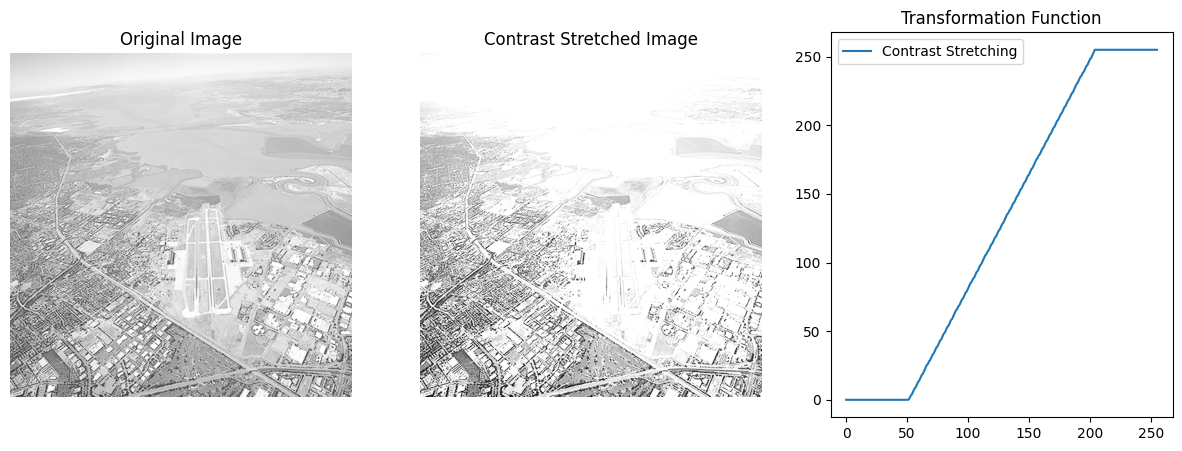

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

f = cv.imread('../MSC Lec notes/3rd sem/Computer Vision/Images/runway.png', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

# Parameters
r1, r2 = 0.2, 0.8

# Create transformation function (lookup table)
t3 = np.zeros(256, dtype=np.uint8)

for i in range(256):
    r = i / 255.0
    if r < r1:
        s = 0
    elif r <= r2:
        s = (r - r1) / (r2 - r1)
    else:
        s = 1
    t3[i] = np.clip(s * 255, 0, 255)

# Apply transformation
g3 = t3[f]


fig, ax = plt.subplots(1, 3, figsize=(15,5))
ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')

ax[1].imshow(g3, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Contrast Stretched Image')

ax[2].plot(t3, label='Contrast Stretching')
ax[2].set_title('Transformation Function')
ax[2].legend()

ax[0].axis('off')
ax[1].axis('off')

plt.show()

**2. (a)Apply gamma correction to the L plane & (b)Show the histograms of the original and corrected images.**

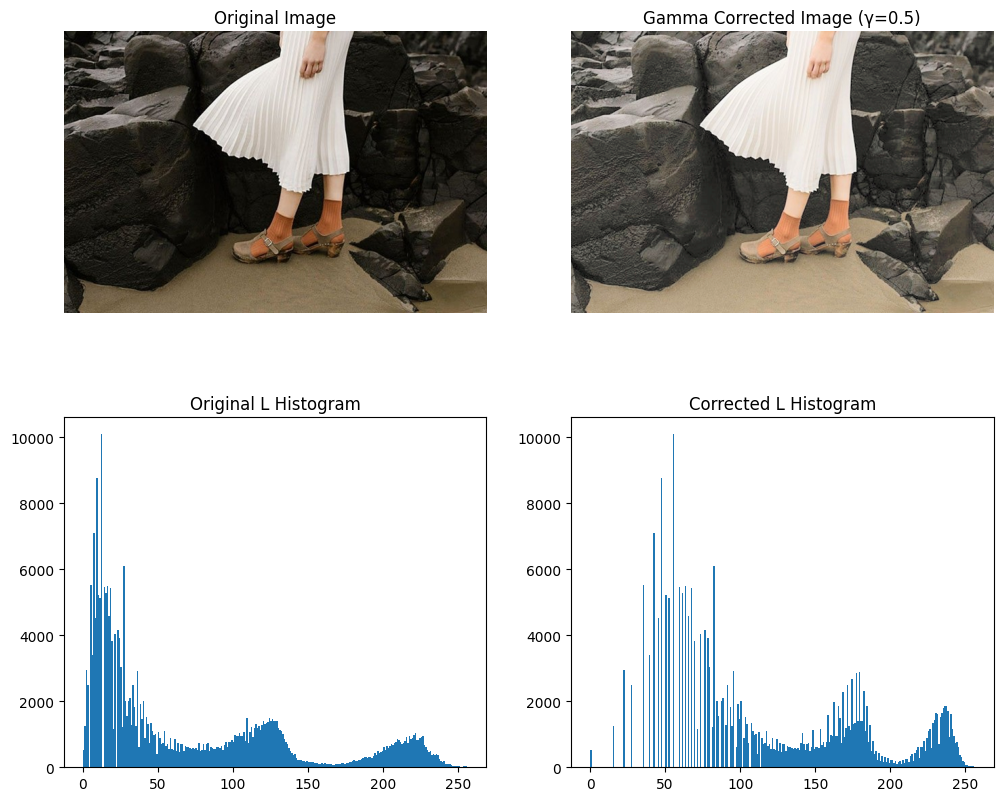

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img = cv.imread('../MSC Lec notes/3rd sem/Computer Vision/Images/Picture1.jpg', cv.IMREAD_COLOR)
assert img is not None, 'Image not found'

# Convert BGR to LAB
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)

# Normalize L channel to [0,1]
L_norm = L / 255.0

# Gamma correction (choose gamma)
gamma = 0.5  

L_gamma = np.power(L_norm, gamma)

# Convert back to [0,255]
L_new = np.uint8(np.clip(L_gamma * 255, 0, 255))

# Merge channels and convert back to BGR
lab_new = cv.merge((L_new, a, b))
img_corrected = cv.cvtColor(lab_new, cv.COLOR_LAB2BGR)

fig, ax = plt.subplots(2, 2, figsize=(12,10))

ax[0,0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax[0,0].set_title('Original Image')

ax[0,1].imshow(cv.cvtColor(img_corrected, cv.COLOR_BGR2RGB))
ax[0,1].set_title(f'Gamma Corrected Image (γ={gamma})')

# Histograms (L channel)
ax[1,0].hist(L.ravel(), bins=256, range=(0,256))
ax[1,0].set_title('Original L Histogram')

ax[1,1].hist(L_new.ravel(), bins=256, range=(0,256))
ax[1,1].set_title('Corrected L Histogram')

ax[0,0].axis('off')
ax[0,1].axis('off')

plt.show()

**3.  Write your own function to equalize the histogram of an image. Apply this function to the runway image.**

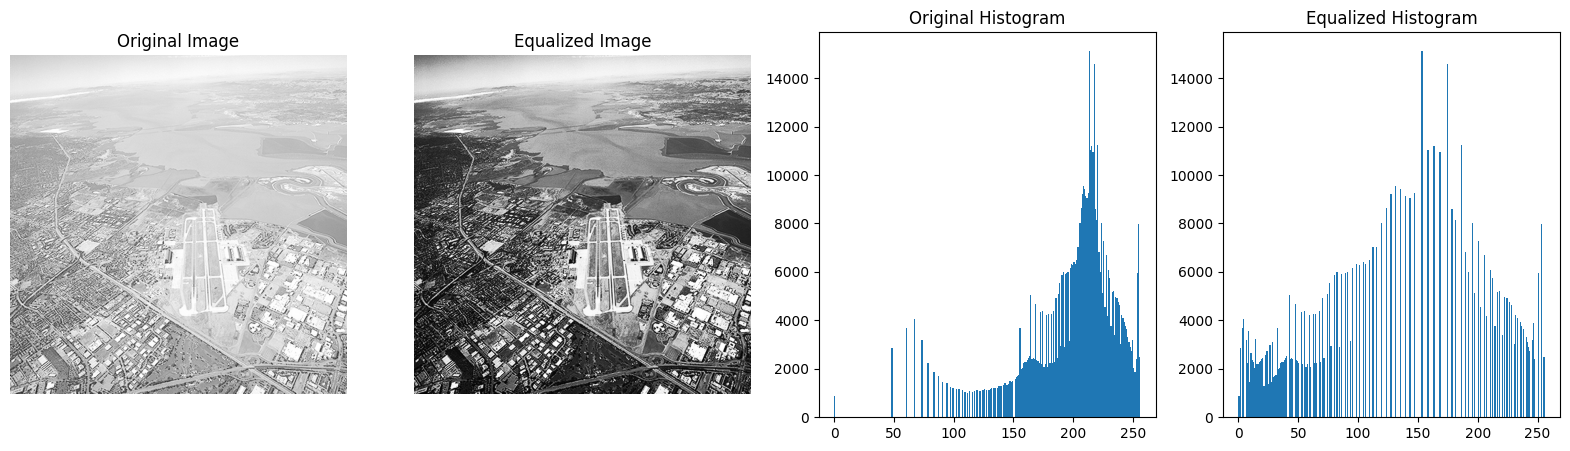

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


f = cv.imread('../MSC Lec notes/3rd sem/Computer Vision/Images/runway.png', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

# Custom histogram equalization function
def my_hist_equalization(img):
    # Histogram
    hist = np.zeros(256)
    for pixel in img.flatten():
        hist[pixel] += 1

    # Normalize histogram (PDF)
    pdf = hist / img.size

    # CDF
    cdf = np.cumsum(pdf)

    # Mapping function
    transform = np.floor(255 * cdf).astype(np.uint8)

    # Apply mapping
    equalized_img = transform[img]

    return equalized_img, hist, transform

# Apply function
g, hist, t = my_hist_equalization(f)


fig, ax = plt.subplots(1, 4, figsize=(20,5))

ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')

ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Equalized Image')

ax[2].hist(f.ravel(), bins=256, range=(0,256))
ax[2].set_title('Original Histogram')

ax[3].hist(g.ravel(), bins=256, range=(0,256))
ax[3].set_title('Equalized Histogram')

ax[0].axis('off')
ax[1].axis('off')

plt.show()

**4. A photo of a woman standing in front of an open window2. Convert this to grayscale.**

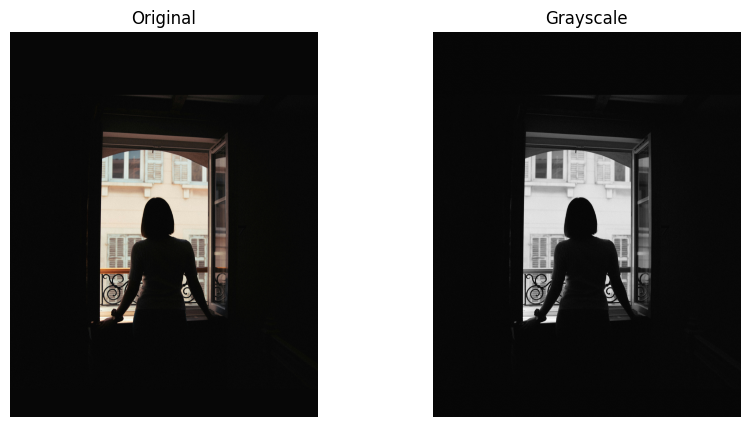

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im = cv.imread('../MSC Lec notes/3rd sem/Computer Vision/Images/fig3.jpg', cv.IMREAD_COLOR)
assert im is not None, 'Image not found'

# convert to grayscale
im_gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(im_gray, cmap='gray')
ax[1].set_title('Grayscale')
ax[1].axis('off')

plt.show()

Otsu Threshold value = 101.0


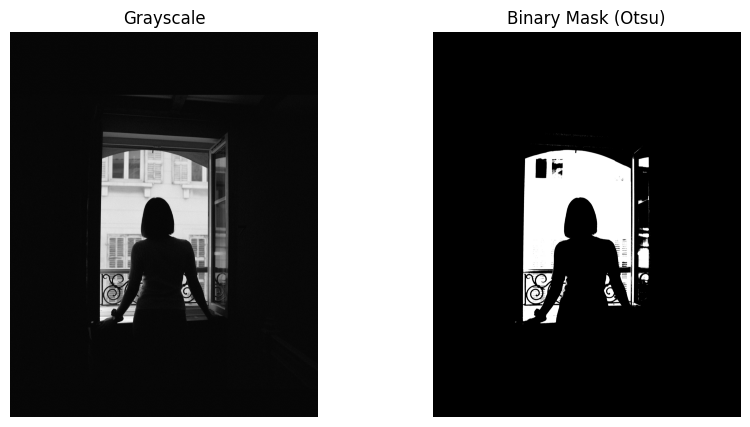

In [7]:
# Part(a) Use Otsu thesholding to obtain the binary mask for the foreground comprising the woman and the room. Report the resulting threshold value.
# Otsu thresholding
ret, th = cv.threshold(im_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

print("Otsu Threshold value =", ret)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(im_gray, cmap='gray')
ax[0].set_title('Grayscale')
ax[0].axis('off')

ax[1].imshow(th, cmap='gray')
ax[1].set_title('Binary Mask (Otsu)')
ax[1].axis('off')

plt.show()

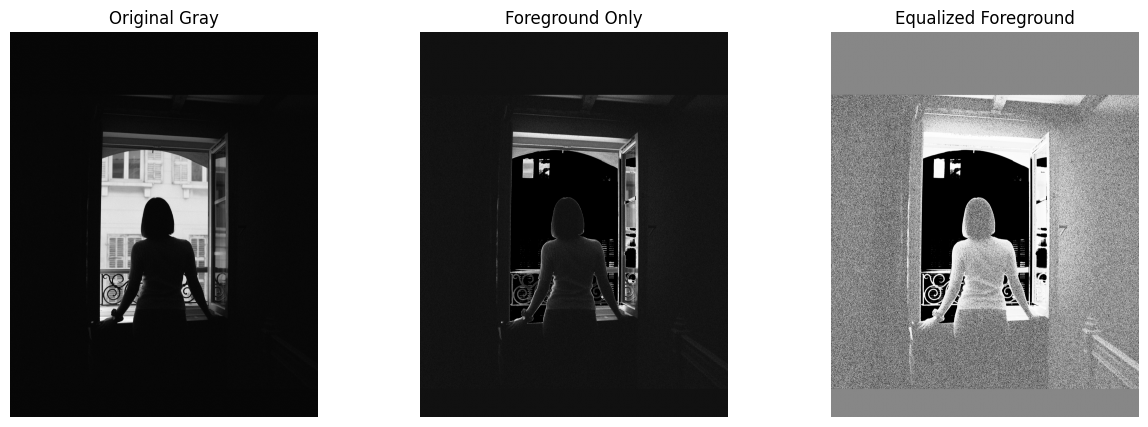

In [ ]:
#Part(b) Carry out histogram equalization only for the foreground region. What are the hidden features that are revealed in the resulting image?

# create foreground mask (woman assumed dark)
mask = th == 0   # foreground

# extract foreground (for display only)
foreground = im_gray.copy()
foreground[~mask] = 0

# apply histogram equalization to whole image
im_eq = cv.equalizeHist(im_gray)

# create result image
result = np.zeros_like(im_gray)
result[mask] = im_eq[mask]   

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(im_gray, cmap='gray')
ax[0].set_title('Original Gray')
ax[0].axis('off')

ax[1].imshow(foreground, cmap='gray')
ax[1].set_title('Foreground Only')
ax[1].axis('off')

ax[2].imshow(result, cmap='gray')
ax[2].set_title('Equalized Foreground')
ax[2].axis('off')

plt.show()


**5. Gaussian filtering**

In [16]:
#Part (a)Using NumPy, compute a normalized 5×5 Gaussian kernel for σ=2.
import numpy as np

def gaussian_kernel(size=5, sigma=2):
    k = size // 2
    kernel = np.zeros((size, size), dtype=np.float32)

    for x in range(-k, k+1):
        for y in range(-k, k+1):
            kernel[x+k, y+k] = np.exp(-(x**2 + y**2) / (2*sigma**2))

    # Normalize
    kernel = kernel / np.sum(kernel)
    return kernel

kernel = gaussian_kernel(5, 2)
print(kernel)

[[0.02324684 0.03382396 0.03832756 0.03382396 0.02324684]
 [0.03382396 0.04921356 0.05576627 0.04921356 0.03382396]
 [0.03832756 0.05576627 0.06319147 0.05576627 0.03832756]
 [0.03382396 0.04921356 0.05576627 0.04921356 0.03382396]
 [0.02324684 0.03382396 0.03832756 0.03382396 0.02324684]]


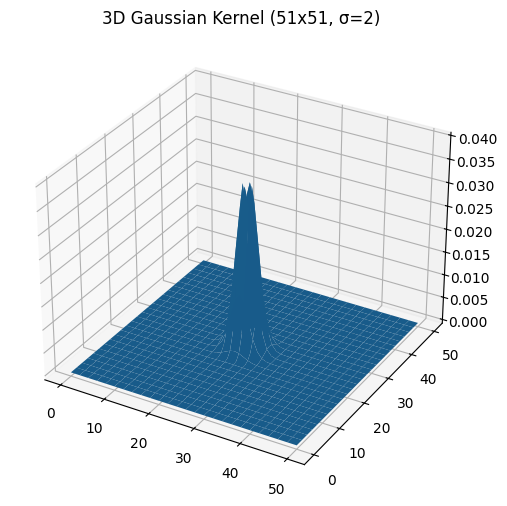

In [17]:
#Part (b) Visualize a 51×51 computed Gaussian kernel as a 3D surface plot, where the kernel coefficients represent the height.
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

kernel_3d = gaussian_kernel(51, 2)

x = np.arange(51)
y = np.arange(51)
X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, kernel_3d)

ax.set_title('3D Gaussian Kernel (51x51, σ=2)')
plt.show()

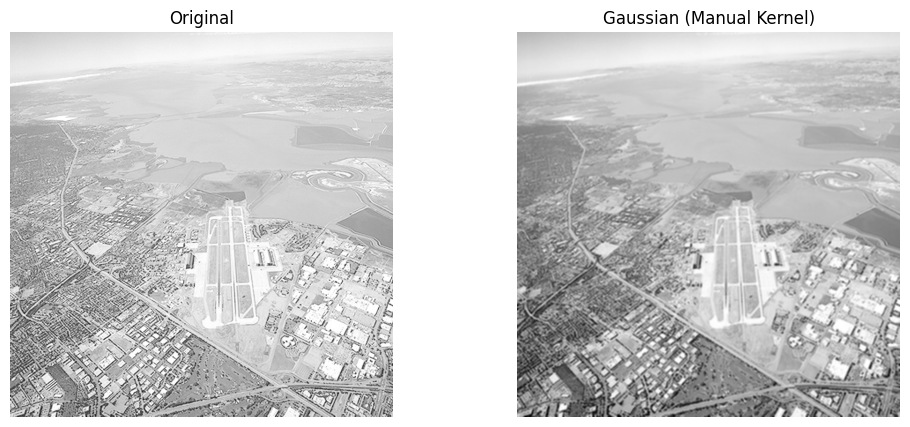

In [19]:
#Part (c)Apply Gaussian smoothing to a given grayscale image using the manually computed Gaussian kernel.
import cv2 as cv

# Read image
f = cv.imread('../MSC Lec notes/3rd sem/Computer Vision/Images/runway.png', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

# Use computed kernel
kernel = gaussian_kernel(5, 2)

# Apply filtering (as in PDF using filter2D)
g_manual = cv.filter2D(f, cv.CV_32F, kernel)

# Display
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].imshow(f, cmap='gray')
ax[0].set_title('Original')

ax[1].imshow(g_manual, cmap='gray')
ax[1].set_title('Gaussian (Manual Kernel)')

for a in ax:
    a.axis('off')

plt.show()

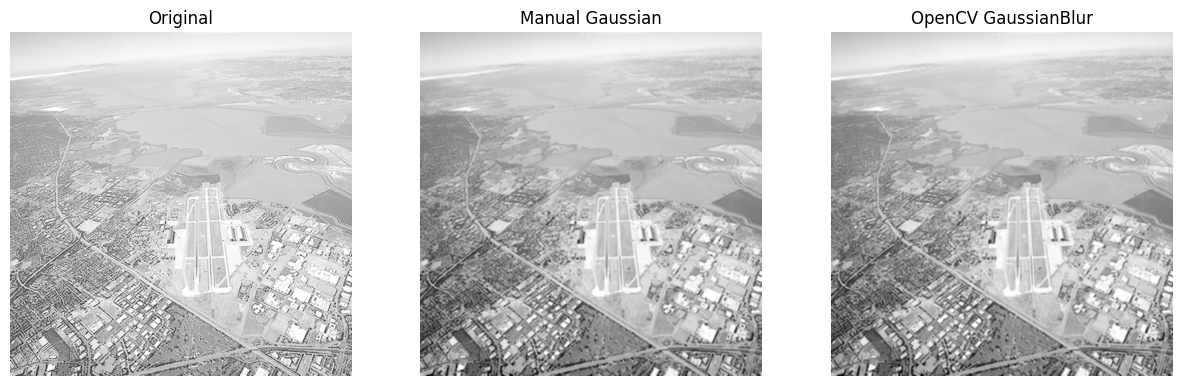

In [20]:
#Part (d)Do the same using OpenCV’s built-in cv.GaussianBlur() function.
# OpenCV Gaussian Blur
g_cv = cv.GaussianBlur(f, (5,5), 2)

# Display comparison
fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(f, cmap='gray')
ax[0].set_title('Original')

ax[1].imshow(g_manual, cmap='gray')
ax[1].set_title('Manual Gaussian')

ax[2].imshow(g_cv, cmap='gray')
ax[2].set_title('OpenCV GaussianBlur')

for a in ax:
    a.axis('off')

plt.show()

**6. Derivative of Gaussian:**

In [21]:
#Part (b)  Using NumPy, compute normalized 5×5 kernels corresponding to the derivatives of a Gaussian for σ=2 in the x- and y-directions.
import numpy as np

def gaussian_derivative_kernels(size=5, sigma=2):
    ax = np.arange(-(size//2), size//2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    G = (1/(2*np.pi*sigma**2)) * np.exp(-(xx**2 + yy**2)/(2*sigma**2))

    Gx = -(xx/(sigma**2)) * G
    Gy = -(yy/(sigma**2)) * G

    # Normalize
    Gx = Gx / np.sum(np.abs(Gx))
    Gy = Gy / np.sum(np.abs(Gy))

    return Gx, Gy

Gx, Gy = gaussian_derivative_kernels()
print(Gx)
print(Gy)

[[ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.07275825  0.05293131 -0.         -0.05293131 -0.07275825]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]]
[[ 0.04413011  0.06420893  0.07275825  0.06420893  0.04413011]
 [ 0.03210446  0.04671172  0.05293131  0.04671172  0.03210446]
 [-0.         -0.         -0.         -0.         -0.        ]
 [-0.03210446 -0.04671172 -0.05293131 -0.04671172 -0.03210446]
 [-0.04413011 -0.06420893 -0.07275825 -0.06420893 -0.04413011]]


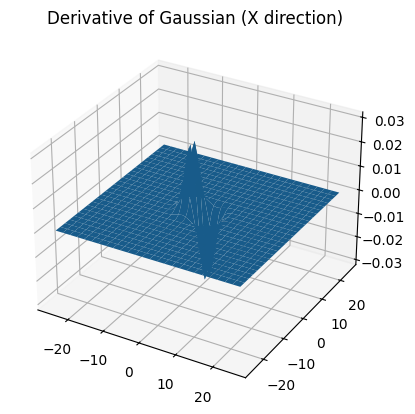

In [22]:
#Part (c)  Visualize a 51×51 derivative-of-Gaussian kernel (for either the x or y direction) as a 3D surface plot, where the kernel coefficients represent the height.
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Gx, _ = gaussian_derivative_kernels(size=51, sigma=2)

x = np.arange(-25, 26)
y = np.arange(-25, 26)
X, Y = np.meshgrid(x, y)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Gx)
ax.set_title("Derivative of Gaussian (X direction)")
plt.show()

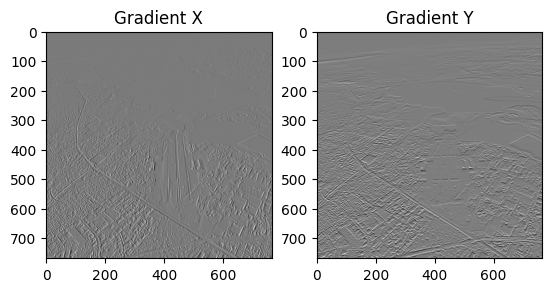

In [24]:
#Part (d) Apply the computed derivative-of-Gaussian kernels to a given grayscale image to obtain the image gradients in the horizontal and vertical directions.
import cv2 as cv
import matplotlib.pyplot as plt

im = cv.imread('../MSC Lec notes/3rd sem/Computer Vision/Images/runway.png', cv.IMREAD_GRAYSCALE)

Gx, Gy = gaussian_derivative_kernels(5, 2)

Ix = cv.filter2D(im, cv.CV_64F, Gx)
Iy = cv.filter2D(im, cv.CV_64F, Gy)



plt.subplot(1,2,1)
plt.imshow(Ix, cmap='gray')
plt.title("Gradient X")

plt.subplot(1,2,2)
plt.imshow(Iy, cmap='gray')
plt.title("Gradient Y")

plt.show()

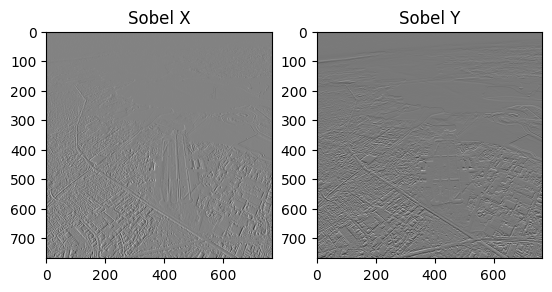

In [25]:
#Part (e) Using OpenCV, compute the image gradients by applying cv.Sobel(). Compare the results with those obtained above and comment on any observed differences.
sobelx = cv.Sobel(im, cv.CV_64F, 1, 0, ksize=5)
sobely = cv.Sobel(im, cv.CV_64F, 0, 1, ksize=5)

plt.subplot(1,2,1)
plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X")

plt.subplot(1,2,2)
plt.imshow(sobely, cmap='gray')
plt.title("Sobel Y")

plt.show()

**7.  Write a program to zoom images by a given factor s∈(0,10].**

SSD (Nearest): 2213.4285
SSD (Bilinear): 1971.1495


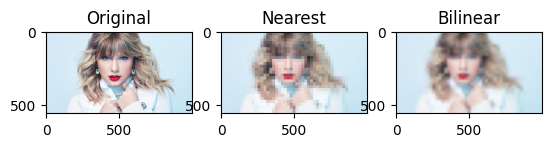

In [ ]:
# Part (a) nearest-neighbor
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

def zoom_image(im, s, method='nearest'):
    # Handle both grayscale and color
    if len(im.shape) == 2:
        h, w = im.shape
        c = 1
    else:
        h, w, c = im.shape

    new_h, new_w = int(h*s), int(w*s)

    if c == 1:
        zoomed = np.zeros((new_h, new_w), dtype=np.float32)
    else:
        zoomed = np.zeros((new_h, new_w, c), dtype=np.float32)

    for i in range(new_h):
        for j in range(new_w):
            x = i / s
            y = j / s

            if method == 'nearest':
                xi, yi = int(round(x)), int(round(y))
                xi = min(xi, h-1)
                yi = min(yi, w-1)

                if c == 1:
                    zoomed[i,j] = im[xi, yi]
                else:
                    zoomed[i,j,:] = im[xi, yi,:]

            elif method == 'bilinear':
                x1, y1 = int(x), int(y)
                x2, y2 = min(x1+1, h-1), min(y1+1, w-1)

                dx, dy = x - x1, y - y1

                if c == 1:
                    zoomed[i,j] = (1-dx)*(1-dy)*im[x1,y1] + \
                                  dx*(1-dy)*im[x2,y1] + \
                                  (1-dx)*dy*im[x1,y2] + \
                                  dx*dy*im[x2,y2]
                else:
                    zoomed[i,j,:] = (1-dx)*(1-dy)*im[x1,y1,:] + \
                                    dx*(1-dy)*im[x2,y1,:] + \
                                    (1-dx)*dy*im[x1,y2,:] + \
                                    dx*dy*im[x2,y2,:]

    return zoomed


def compute_ssd(im1, im2):
    im1 = im1.astype(np.float32)
    im2 = im2.astype(np.float32)

    ssd = np.sum((im1 - im2)**2)
    norm_ssd = ssd / (im1.shape[0] * im1.shape[1])

    return norm_ssd


large = cv.imread('../MSC Lec notes/3rd sem/Computer Vision/scale_im/taylor.jpg', cv.IMREAD_COLOR)
small = cv.imread('../MSC Lec notes/3rd sem/Computer Vision/scale_im/taylor_very_small.jpg', cv.IMREAD_COLOR)

# Compute scale factor
s = large.shape[0] / small.shape[0]

# Zoom
zoom_nn = zoom_image(small, s, 'nearest')
zoom_bl = zoom_image(small, s, 'bilinear')

# Resize to exact match (safety)
zoom_nn = cv.resize(zoom_nn, (large.shape[1], large.shape[0]))
zoom_bl = cv.resize(zoom_bl, (large.shape[1], large.shape[0]))

# SSD
ssd_nn = compute_ssd(large, zoom_nn)
ssd_bl = compute_ssd(large, zoom_bl)

print("SSD (Nearest):", ssd_nn)
print("SSD (Bilinear):", ssd_bl)

# Convert BGR → RGB for correct display
large_rgb = cv.cvtColor(large, cv.COLOR_BGR2RGB)
zoom_nn_rgb = cv.cvtColor(zoom_nn.astype(np.uint8), cv.COLOR_BGR2RGB)
zoom_bl_rgb = cv.cvtColor(zoom_bl.astype(np.uint8), cv.COLOR_BGR2RGB)

plt.subplot(1,3,1)
plt.imshow(large_rgb)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(zoom_nn_rgb)
plt.title("Nearest")

plt.subplot(1,3,3)
plt.imshow(zoom_bl_rgb)
plt.title("Bilinear")

plt.show()

**8.  Gaussian smoothing and median filtering.**

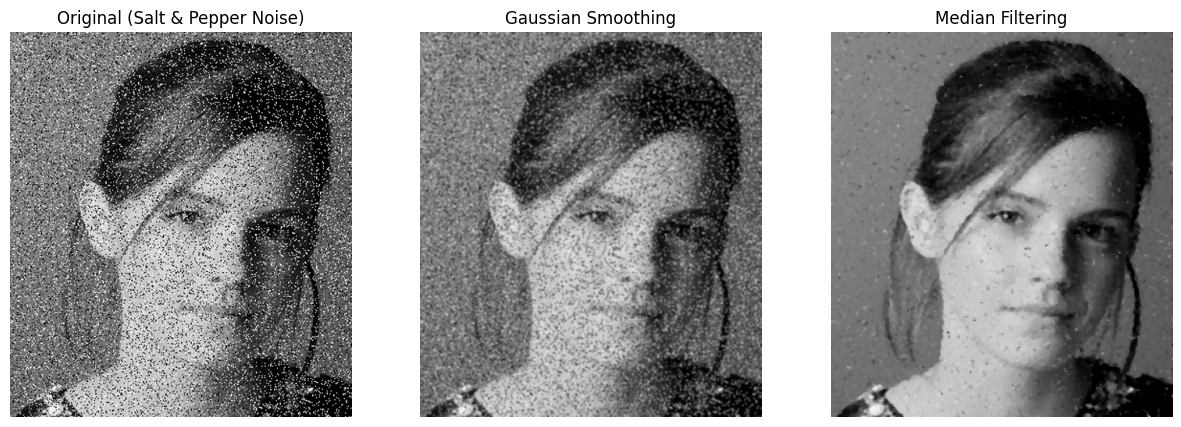

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


f = cv.imread('../MSC Lec notes/3rd sem/Computer Vision/Images/emma2.png')
assert f is not None, 'Image not found'


f_rgb = cv.cvtColor(f, cv.COLOR_BGR2RGB)

# (a) Gaussian smoothing
g_gaussian = cv.GaussianBlur(f_rgb, (5, 5), 1)

# (b) Median filtering
g_median = cv.medianBlur(f_rgb, 5)


fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(f_rgb)
ax[0].set_title('Original (Salt & Pepper Noise)')

ax[1].imshow(g_gaussian)
ax[1].set_title('Gaussian Smoothing')

ax[2].imshow(g_median)
ax[2].set_title('Median Filtering')

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')

plt.show()

**9. Carry out image sharpening on am image of your choice.**

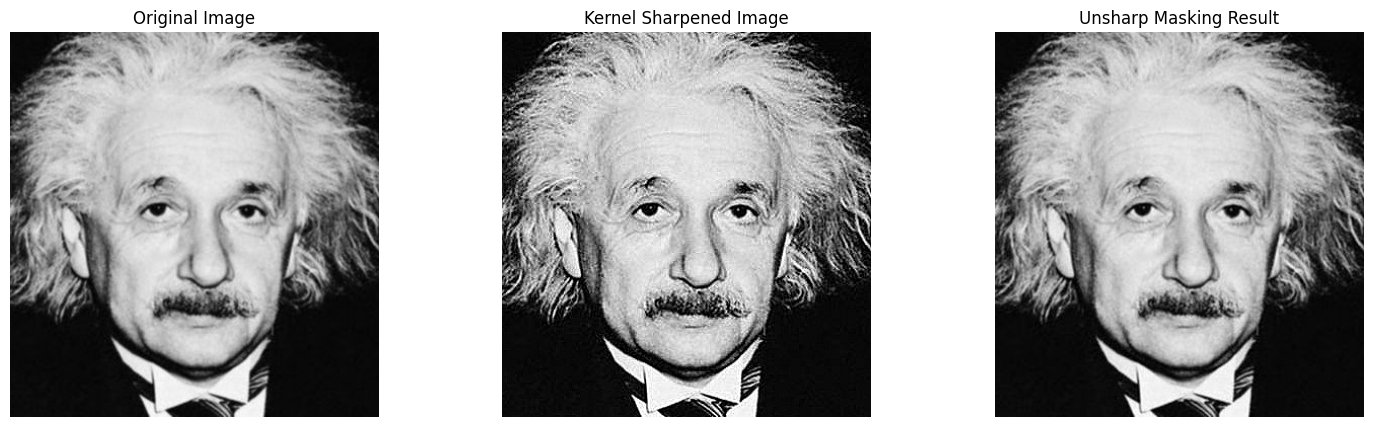

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


f = cv.imread('../MSC Lec notes/3rd sem/Computer Vision/Images2/a1images/einstein.png', cv.IMREAD_GRAYSCALE)
assert f is not None, 'Image not found'

# Create sharpening kernel
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

# Apply filter (sharpening)
g = cv.filter2D(f, -1, kernel)

# Unsharp masking (optional comparison)
blur = cv.GaussianBlur(f, (5, 5), 0)
unsharp = cv.addWeighted(f, 1.5, blur, -0.5, 0)


fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')

ax[1].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Kernel Sharpened Image')

ax[2].imshow(unsharp, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Unsharp Masking Result')

for i in range(3):
    ax[i].axis('off')

plt.show()

**10. Bilateral filtering**

In [12]:
#Part (a)  Python function to manually implement a bilateral filter for grayscale images.

import numpy as np
import cv2

def gaussian(x, sigma):
    
    return np.exp(-(x ** 2) / (2 * (sigma ** 2)))


def bilateral_filter_manual(image, diameter, sigma_s, sigma_r):

    # Apply bilateral filtering manually on a grayscale image.

    # Parameters:
    #     image      : Input grayscale image (uint8)
    #     diameter   : Kernel size (odd integer)
    #     sigma_s    : Spatial standard deviation
    #     sigma_r    : Range (intensity) standard deviation

    # Returns:
    #     filtered_image : Output image after bilateral filtering
  
    image = image.astype(np.float32)
    padded = np.pad(image, diameter // 2, mode='reflect')
    
    h, w = image.shape
    filtered = np.zeros_like(image)

    # Precompute spatial Gaussian
    half = diameter // 2
    x, y = np.meshgrid(np.arange(-half, half+1), np.arange(-half, half+1))
    spatial_weights = gaussian(np.sqrt(x**2 + y**2), sigma_s)

    for i in range(h):
        for j in range(w):
            local_region = padded[i:i+diameter, j:j+diameter]
            
            # Range Gaussian
            intensity_diff = local_region - image[i, j]
            range_weights = gaussian(intensity_diff, sigma_r)

            # Combined weights
            weights = spatial_weights * range_weights

            # Normalization
            filtered[i, j] = np.sum(weights * local_region) / np.sum(weights)

    return np.clip(filtered, 0, 255).astype(np.uint8)

In [13]:
#Part (b) Apply Gaussian smoothing using OpenCV’s cv.GaussianBlur() function.
def gaussian_smoothing(image, kernel_size=5, sigma=1.0):
    #Apply Gaussian smoothing using OpenCV.
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)

In [14]:
#Part (c)  Bilateral filtering using OpenCV’s cv.bilateralFilter() function.
def bilateral_opencv(image, diameter=9, sigma_s=75, sigma_r=75):
    # Apply bilateral filter using OpenCV.
    return cv2.bilateralFilter(image, diameter, sigma_r, sigma_s)

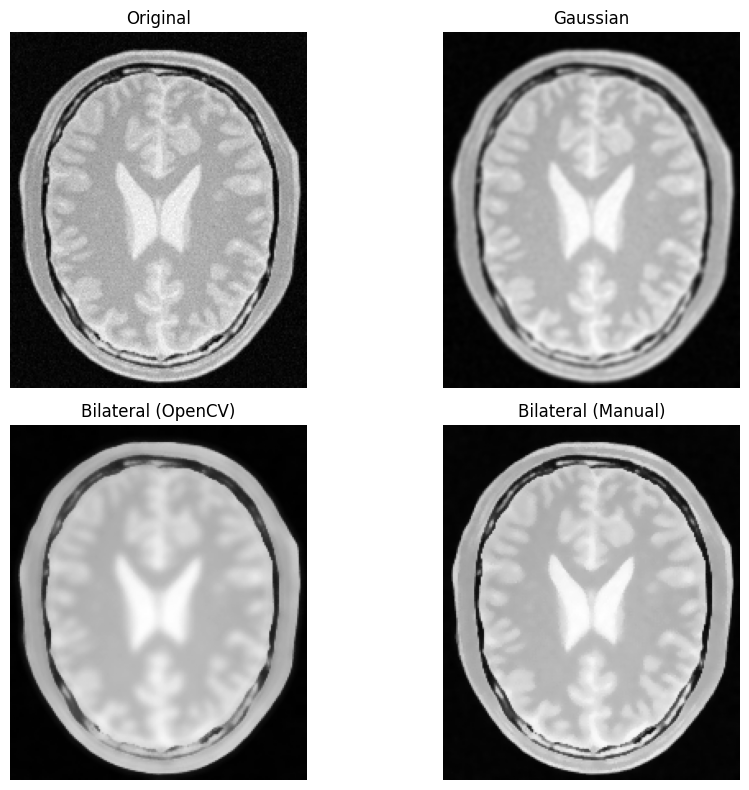

In [15]:
#Part (d)  Manually implemented bilateral filter from part (a).
import matplotlib.pyplot as plt

def apply_all_filters(image_path):

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply filters
    gaussian_img = gaussian_smoothing(image)
    bilateral_cv = bilateral_opencv(image)
    bilateral_manual = bilateral_filter_manual(image, diameter=5, sigma_s=10, sigma_r=20)

    titles = ['Original', 'Gaussian', 'Bilateral (OpenCV)', 'Bilateral (Manual)']
    images = [image, gaussian_img, bilateral_cv, bilateral_manual]

    plt.figure(figsize=(10, 8))
    for i in range(4):
        plt.subplot(2, 2, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    image_path = "../MSC Lec notes/3rd sem/Computer Vision/Images2/a1images/brain.png"  
    apply_all_filters(image_path)